In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

In [2]:
from google.colab import files
uploaded = files.upload()


Saving StackOverflow_Salary_Prediction.csv to StackOverflow_Salary_Prediction.csv


In [4]:
df = pd.read_csv("/content/StackOverflow_Salary_Prediction.csv")

In [5]:
df.head()


,Age,Country,Education,YearsExperience,JobRole,ProgrammingLanguage,CompanySize,RemoteWork,AnnualSalaryUSD
0,60,UK,Bachelor's,7,Frontend Developer,Java,11-50,Onsite,58858
1,54,Brazil,High School,5,Backend Developer,Python,1-10,Remote,30123
2,52,Germany,High School,1,DevOps Engineer,Go,1000+,Hybrid,44723
3,48,Canada,Bachelor's,17,DevOps Engineer,JavaScript,51-200,Hybrid,87594
4,33,USA,Bachelor's,21,Data Scientist,Python,51-200,Hybrid,144282


In [6]:
df.shape

(50000, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  50000 non-null  int64 
 1   Country              50000 non-null  object
 2   Education            50000 non-null  object
 3   YearsExperience      50000 non-null  int64 
 4   JobRole              50000 non-null  object
 5   ProgrammingLanguage  50000 non-null  object
 6   CompanySize          50000 non-null  object
 7   RemoteWork           50000 non-null  object
 8   AnnualSalaryUSD      50000 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 3.4+ MB


In [8]:
df.isnull().sum()

,0
Age,0
Country,0
Education,0
YearsExperience,0
JobRole,0
ProgrammingLanguage,0
CompanySize,0
RemoteWork,0
AnnualSalaryUSD,0


In [9]:
df = df.dropna()

df.shape



(50000, 9)

In [10]:
df = df.drop_duplicates()

df.shape

(50000, 9)

In [11]:
def experience_level(years):
    if years <= 2:
        return "Beginner"
    elif years <= 5:
        return "Intermediate"
    elif years <= 10:
        return "Experienced"
    else:
        return "Expert"

df["ExperienceLevel"] = df["YearsExperience"].apply(experience_level)


In [12]:
def salary_level(salary):
    if salary < 50000:
        return "Low"
    elif salary < 100000:
        return "Medium"
    else:
        return "High"

df["SalaryLevel"] = df["AnnualSalaryUSD"].apply(salary_level)

In [13]:
def age_group(age):
    if age < 25:
        return "Young"
    elif age < 35:
        return "Adult"
    elif age < 50:
        return "Senior"
    else:
        return "Experienced"

df["AgeGroup"] = df["Age"].apply(age_group)

In [14]:
def work_mode(mode):
    if mode == "Yes":
        return "Remote"
    elif mode == "No":
        return "Onsite"
    else:
        return "Hybrid"

df["WorkMode"] = df["RemoteWork"].apply(work_mode)

In [15]:
df.head()

,Age,Country,Education,YearsExperience,JobRole,ProgrammingLanguage,CompanySize,RemoteWork,AnnualSalaryUSD,ExperienceLevel,SalaryLevel,AgeGroup,WorkMode
0,60,UK,Bachelor's,7,Frontend Developer,Java,11-50,Onsite,58858,Experienced,Medium,Experienced,Hybrid
1,54,Brazil,High School,5,Backend Developer,Python,1-10,Remote,30123,Intermediate,Low,Experienced,Hybrid
2,52,Germany,High School,1,DevOps Engineer,Go,1000+,Hybrid,44723,Beginner,Low,Experienced,Hybrid
3,48,Canada,Bachelor's,17,DevOps Engineer,JavaScript,51-200,Hybrid,87594,Expert,Medium,Senior,Hybrid
4,33,USA,Bachelor's,21,Data Scientist,Python,51-200,Hybrid,144282,Expert,High,Adult,Hybrid


In [16]:
# Create Monthly Salary column
df["MonthlySalaryUSD"] = (df["AnnualSalaryUSD"] / 12).round(2)

# Display the new column
df[["AnnualSalaryUSD", "MonthlySalaryUSD"]].head()

,AnnualSalaryUSD,MonthlySalaryUSD
0,58858,4904.83
1,30123,2510.25
2,44723,3726.92
3,87594,7299.50
4,144282,12023.50


In [17]:
df.head()

,Age,Country,Education,YearsExperience,JobRole,ProgrammingLanguage,CompanySize,RemoteWork,AnnualSalaryUSD,ExperienceLevel,SalaryLevel,AgeGroup,WorkMode,MonthlySalaryUSD
0,60,UK,Bachelor's,7,Frontend Developer,Java,11-50,Onsite,58858,Experienced,Medium,Experienced,Hybrid,4904.83
1,54,Brazil,High School,5,Backend Developer,Python,1-10,Remote,30123,Intermediate,Low,Experienced,Hybrid,2510.25
2,52,Germany,High School,1,DevOps Engineer,Go,1000+,Hybrid,44723,Beginner,Low,Experienced,Hybrid,3726.92
3,48,Canada,Bachelor's,17,DevOps Engineer,JavaScript,51-200,Hybrid,87594,Expert,Medium,Senior,Hybrid,7299.50
4,33,USA,Bachelor's,21,Data Scientist,Python,51-200,Hybrid,144282,Expert,High,Adult,Hybrid,12023.50


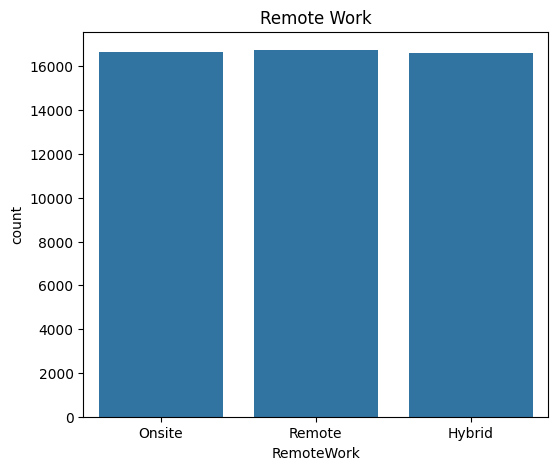

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(x="RemoteWork", data=df)

plt.title("Remote Work")

plt.show()

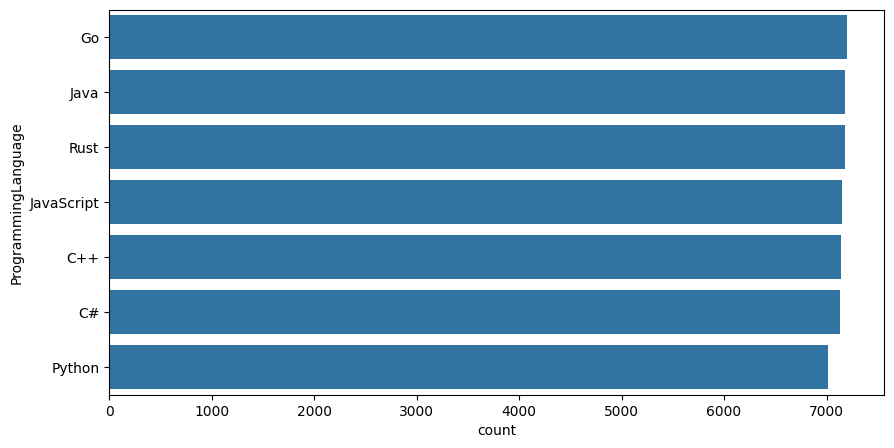

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(y="ProgrammingLanguage",
              data=df,
              order=df["ProgrammingLanguage"].value_counts().index)

plt.show()

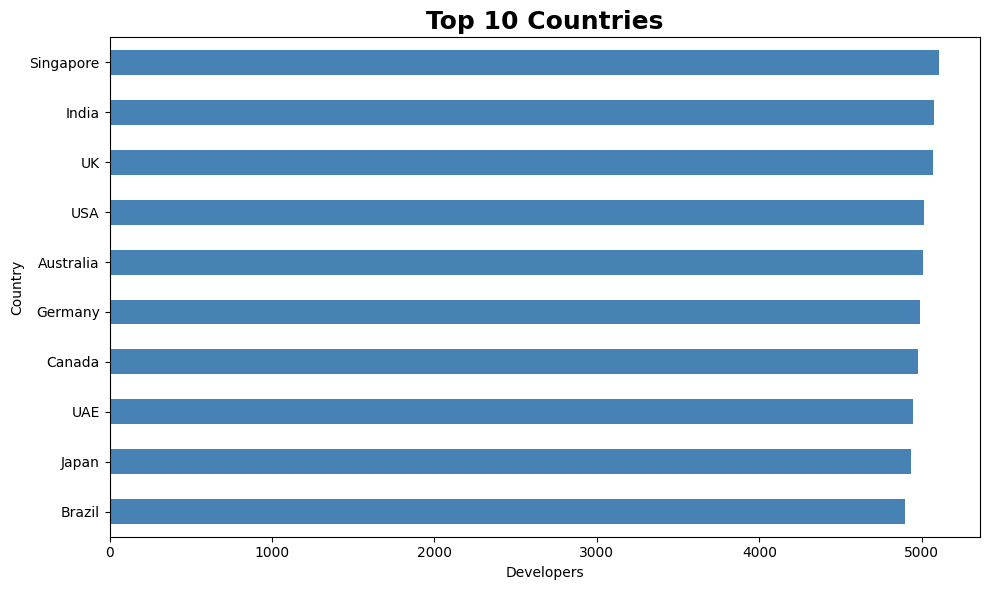

In [20]:
top_country=df["Country"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_country.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Countries",fontsize=18,fontweight="bold")

plt.xlabel("Developers")

plt.tight_layout()

plt.show()

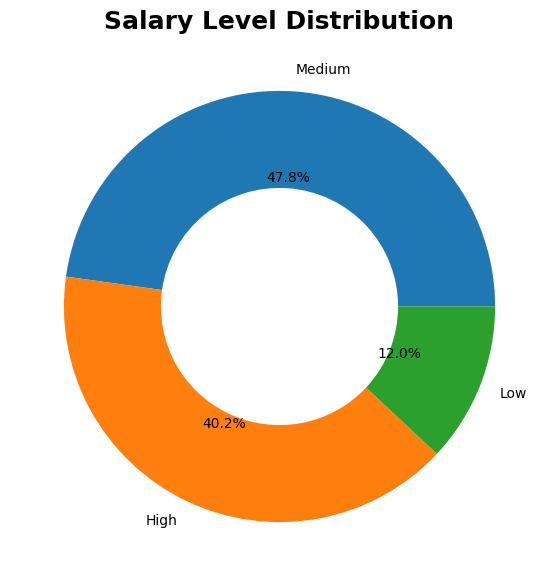

In [21]:
salary=df["SalaryLevel"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    salary,
    labels=salary.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.45)
)

plt.title("Salary Level Distribution",fontsize=18,fontweight="bold")

plt.show()

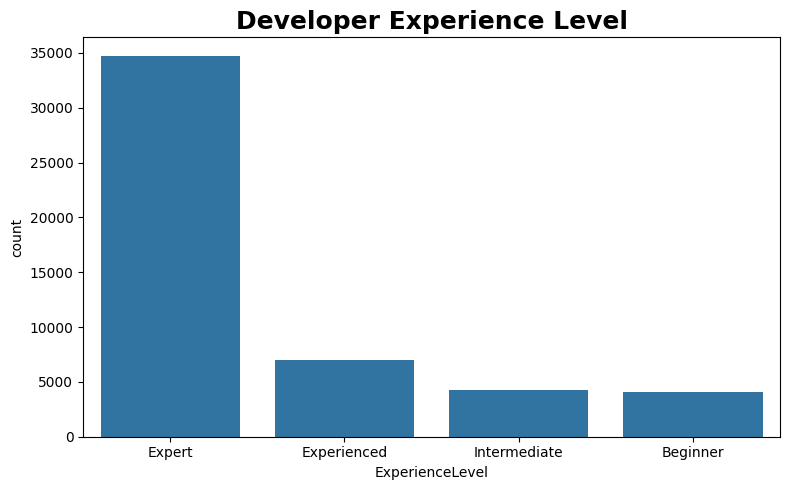

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ExperienceLevel",
    order=df["ExperienceLevel"].value_counts().index
)

plt.title("Developer Experience Level",fontsize=18,fontweight="bold")

plt.tight_layout()

plt.show()

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [25]:
X = df.drop(columns=["AnnualSalaryUSD", "RemoteWork", "SalaryLevel", "MonthlySalaryUSD"])
y = df["AnnualSalaryUSD"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = ["Age", "YearsExperience"]
categorical_features = ["Country", "Education", "JobRole", "ProgrammingLanguage", "CompanySize", "ExperienceLevel", "AgeGroup", "WorkMode"]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [26]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['Age', 'YearsExperience']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Country', 'Education',
                                                   'JobRole',
                                                   'ProgrammingLanguage',
                                                   'CompanySize',
                                                   'ExperienceLevel',
                                                   'AgeGroup', 'WorkMode'])])),
                ('regressor', LinearRegression())])

In [27]:
predictions = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, predictions))
print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 Score :", r2_score(y_test, predictions))

MAE : 5059.44174133566
RMSE : 5831.149341476979
R2 Score : 0.9697774922983523


In [29]:
sample = pd.DataFrame({
    "Age": [25],
    "YearsExperience": [3],
    "Country": ["India"],
    "Education": ["Bachelor's"],
    "JobRole": ["Data Scientist"],
    "ProgrammingLanguage": ["Python"],
    "CompanySize": ["201-500"],
    "RemoteWork": ["Hybrid"],
    "ExperienceLevel": ["Intermediate"],
    "AgeGroup": ["Adult"],
    "WorkMode": ["Hybrid"]
})

predicted_salary = model.predict(sample)

print("Predicted Annual Salary (USD):", predicted_salary[0])

Predicted Annual Salary (USD): 39499.45130291436
